<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
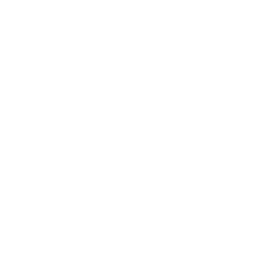
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Konstruktion eines Gen-Koexpressionsnetzwerks</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotech / Genomforschung &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Dieses Beispiel verwendet **PROC CORR**, um aus einem synthetischen Expressionspanel im RNA-seq-Stil ein Gen-Koexpressionsnetzwerk zu konstruieren. Das Panel enthält **9 Gene**, die drei funktionalen Modulen zugeordnet sind — *immune*, *cell-cycle* und *metabolic* (je drei Gene) —, gemessen über **100 Tumorproben**. Durchgehend wird die Spearman-Rangkorrelation verwendet, weil Expressionsdaten typischerweise nicht normalverteilt sind und Ausreißer enthalten, sodass ein rangbasierter Koeffizient robuster ist als Pearson.

Die Analyse gewinnt die eingebaute modulare Struktur direkt aus den Daten zurück. Liest man die unten erzeugte Spearman-Matrix, fällt die mittlere Korrelation innerhalb der Module von **rho 0.67 für das Immunmodul** über **0.36 für cell-cycle** auf **0.17 für metabolic**, was die abnehmende Signal-Rausch-Ladung widerspiegelt, die in jedes Modul eingebaut ist. Die Korrelationen zwischen den Modulen liegen im Mittel praktisch bei null (mittleres rho etwa **-0.01**, mittleres |rho| **0.07**), sodass sich die drei Module wie nahezu unabhängige Koexpressionsgemeinschaften verhalten. Jede hier genannte Zahl ist der PROC-CORR-Ausgabe in diesem Notebook entnommen.

> **Hinweis zum Umfang.** Dieses Notebook läuft unter der unlizenzierten Obergrenze von 100 Beobachtungen, sodass der Stichprobenumfang 100 beträgt und das Panel auf 9 Gene beschränkt bleibt — klein genug, dass die vollständige Korrelationsmatrix, die umgeformte Paarliste und die Heatmap alle vollständig und exakt sind, ohne Abschneiden. Jede Tabelle und Abbildung spiegelt genau das wider, was berechnet wurde.

## Daten

| Datenmenge | Beschreibung | Zeilen |
|---------|-------------|------|
| `WORK.EXPR` | Log-skalierte Expression für 9 Gene (3 Module x 3 Gene) über Tumorproben | 100 |

Der Generator zieht drei latente Modulsignale je Probe. Jedes Gen lädt auf das Signal seines eigenen Moduls plus unabhängiges Rauschen, sodass Koexpression nur innerhalb eines Moduls entsteht. Das Immunmodul verwendet die größte Signalladung und das metabolische Modul die kleinste, was der Gradient ist, den die Korrelationsanalyse zurückgewinnen sollte.

---

In [1]:
/* --------------------------------------------------------
   Synthetisches Expressions-Panel: 9 Gene, 3 Module, 100 Proben
     imm1-imm3  Immun        (starkes gemeinsames Signal)
     cyc1-cyc3  Zellzyklus   (mittleres gemeinsames Signal)
     met1-met3  Stoffwechsel (schwaches gemeinsames Signal)
   Jedes Gen = Modul-Signal + unabhängiges genspezifisches Rauschen.
   -------------------------------------------------------- */
DATEN work.expr;
    AUFRUFEN streaminit(42);
    FELD imm[3]; FELD cyc[3]; FELD met[3];
    AUSFÜHRUNG sample_id = 1 BIS 100;
        s_imm = rand('normal', 0, 1.5);   /* latentes Immun-Signal        */
        s_cyc = rand('normal', 0, 1.2);   /* latentes Zellzyklus-Signal   */
        s_met = rand('normal', 0, 1.0);   /* latentes Stoffwechsel-Signal */
        AUSFÜHRUNG j = 1 BIS 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        ENDE;
        AUSFÜHRUNG j = 1 BIS 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        ENDE;
        AUSFÜHRUNG j = 1 BIS 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        ENDE;
        AUSGABE;
    ENDE;
    BEHALTEN imm1-imm3 cyc1-cyc3 met1-met3;
AUSFÜHREN;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   Genweise Expressions-Zusammenfassung (Mittelwert und Streuung je Modul)
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.expr n mean std maxdec=3;
    VAR imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    TITEL 'Genexpressions-Übersicht (9-Gen-Panel, N=100)';
AUSFÜHREN;
TITEL;

                                     Genexpressions-Übersicht (9-Gen-Panel, N=100)                                      

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev
 ------------------------------------------
 imm1           100       6.042       1.125
 imm2           100       5.925       1.122
 imm3           100       5.863       1.273
 cyc1           100       6.947       1.034
 cyc2           100       7.003       1.002
 cyc3           100       6.861       1.040
 met1           100       5.144       0.940
 met2           100       4.989       0.789
 met3           100       5.015       0.979
 ------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Die Mittelwerte gruppieren sich nahe der Basislinie jedes Moduls (immune ~6, cell cycle ~7, metabolic ~5), und jedes Gen hat eine vergleichbare Streuung, sodass kein einzelnes Gen die nachfolgende Korrelationsstruktur dominiert.

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


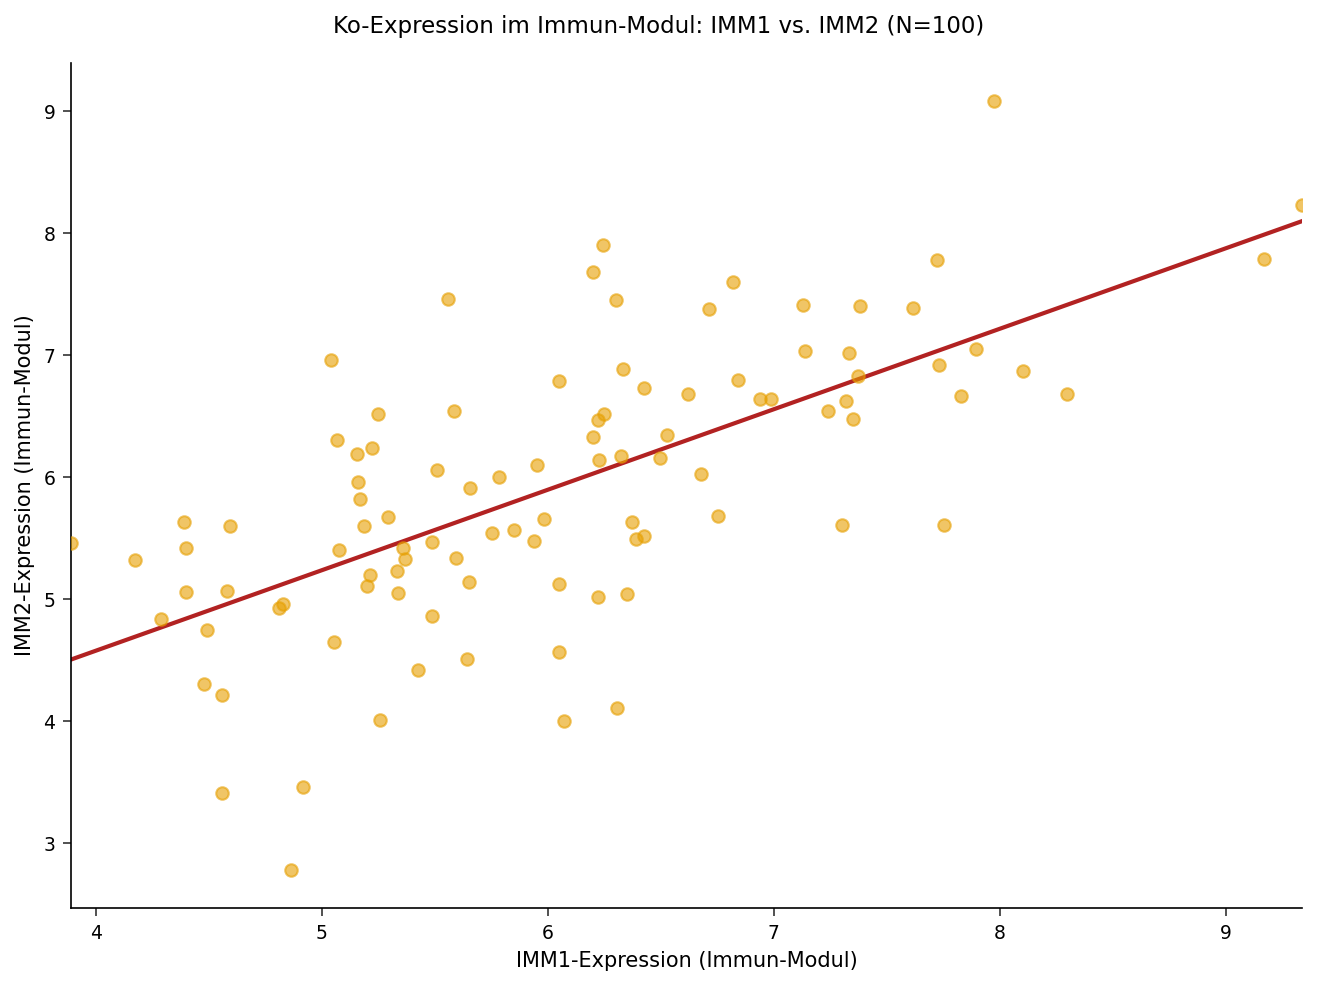

In [3]:
/* --------------------------------------------------------
   Streudiagramm zweier Immun-Modul-Gene: eine visuelle Prüfung,
   dass die Ko-Expression innerhalb des Moduls real und
   annähernd monoton ist
   -------------------------------------------------------- */
PROZEDUR SGPLOT DATEN=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS BEZEICHNUNG='IMM1-Expression (Immun-Modul)';
    YAXIS BEZEICHNUNG='IMM2-Expression (Immun-Modul)';
    TITEL 'Ko-Expression im Immun-Modul: IMM1 vs. IMM2 (N=100)';
AUSFÜHREN;
TITEL;

Der aufsteigende Trend bestätigt, dass die beiden Immungene gemeinsam steigen und fallen — das visuelle Gegenstück zu ihrer positiven Spearman-Korrelation in der Matrix unten.

---

In [4]:
/* --------------------------------------------------------
   Spearman-Korrelation über alle 9 Gene
   nosimple unterdrückt den Block der einfachen Statistiken;
   outs= schreibt die Spearman-Matrix für die folgenden Netzwerk-Schritte
   -------------------------------------------------------- */
PROZEDUR CORR DATEN=work.expr spearman nosimple
    outs=work.gene_corr;
    VAR imm1-imm3 cyc1-cyc3 met1-met3;
    TITEL 'Spearman-Korrelationsmatrix: 9-Gen-Ko-Expressions-Panel';
AUSFÜHREN;
TITEL;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/7ae30ed0-99da-4814-896c-123153b7a7da/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


Lesen Sie die Matrix als drei Diagonalblöcke. Der **immune**-Block (IMM1-IMM3) ist am engsten koexprimiert (rho etwa 0.63 bis 0.72), der **cell-cycle**-Block (CYC1-CYC3) ist moderat (etwa 0.29 bis 0.41), und der **metabolic**-Block (MET1-MET3) ist am schwächsten (etwa 0.13 bis 0.25). Einträge außerhalb der Blöcke — Paare von Genen in verschiedenen Modulen — liegen nahe null. Die nächste Zelle quantifiziert den Kontrast innerhalb versus zwischen den Modulen, und die darauf folgende Heatmap macht die Blockstruktur sichtbar.

---

In [5]:
/* --------------------------------------------------------
   Die Korrelationsmatrix (eine Zeile je Gen) in Langform
   (gene_x, gene_y, rho) umformen und jedes Paar als innerhalb-
   oder zwischen-Modul kennzeichnen. 9 Gene -> 81 Paar-Zeilen,
   es geht also nichts durch die 100-Beobachtungs-Grenze verloren.
   -------------------------------------------------------- */
DATEN work.corr_long;
    FESTLEGEN work.gene_corr(WO=(_TYPE_='SCORR'));
    LÄNGE gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    FELD g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    FELD gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    AUSFÜHRUNG k = 1 BIS 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        AUSGABE;
    ENDE;
    BEHALTEN gene_x gene_y rho mod_x mod_y same_module;
AUSFÜHREN;

/* --------------------------------------------------------
   Innerhalb- vs. Zwischen-Modul Spearman-Rho (nur ausserhalb der Diagonale)
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.corr_long(WO=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    KLASSE same_module;
    VAR rho;
    BEZEICHNUNG rho='Spearman-Rho' same_module='Modul-Beziehung';
    TITEL 'Spearman-Rho: Innerhalb (1) vs. Zwischen (0) Module';
AUSFÜHREN;
TITEL;

                                  Spearman-Rho: Innerhalb (1) vs. Zwischen (0) Module                                   

                                                  The MEANS Procedure

                                         Analysis Variable : rho Spearman-Rho

                                                   N
                              Modul-Beziehung    Obs        Mean      Minimum      Maximum
                              ------------------------------------------------------------
                              0                   54      -0.007       -0.185        0.162
                              1                   18       0.402        0.127        0.718
                              ------------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Die Zeile `same_module=1` aggregiert die Paare innerhalb der Module und `same_module=0` die Paare zwischen den Modulen. Die Korrelation innerhalb der Module ist im Mittel deutlich positiv, während die Korrelation zwischen den Modulen im Mittel nahe null liegt, was bestätigt, dass die Module als nahezu unabhängige Koexpressionsgemeinschaften wirken.

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


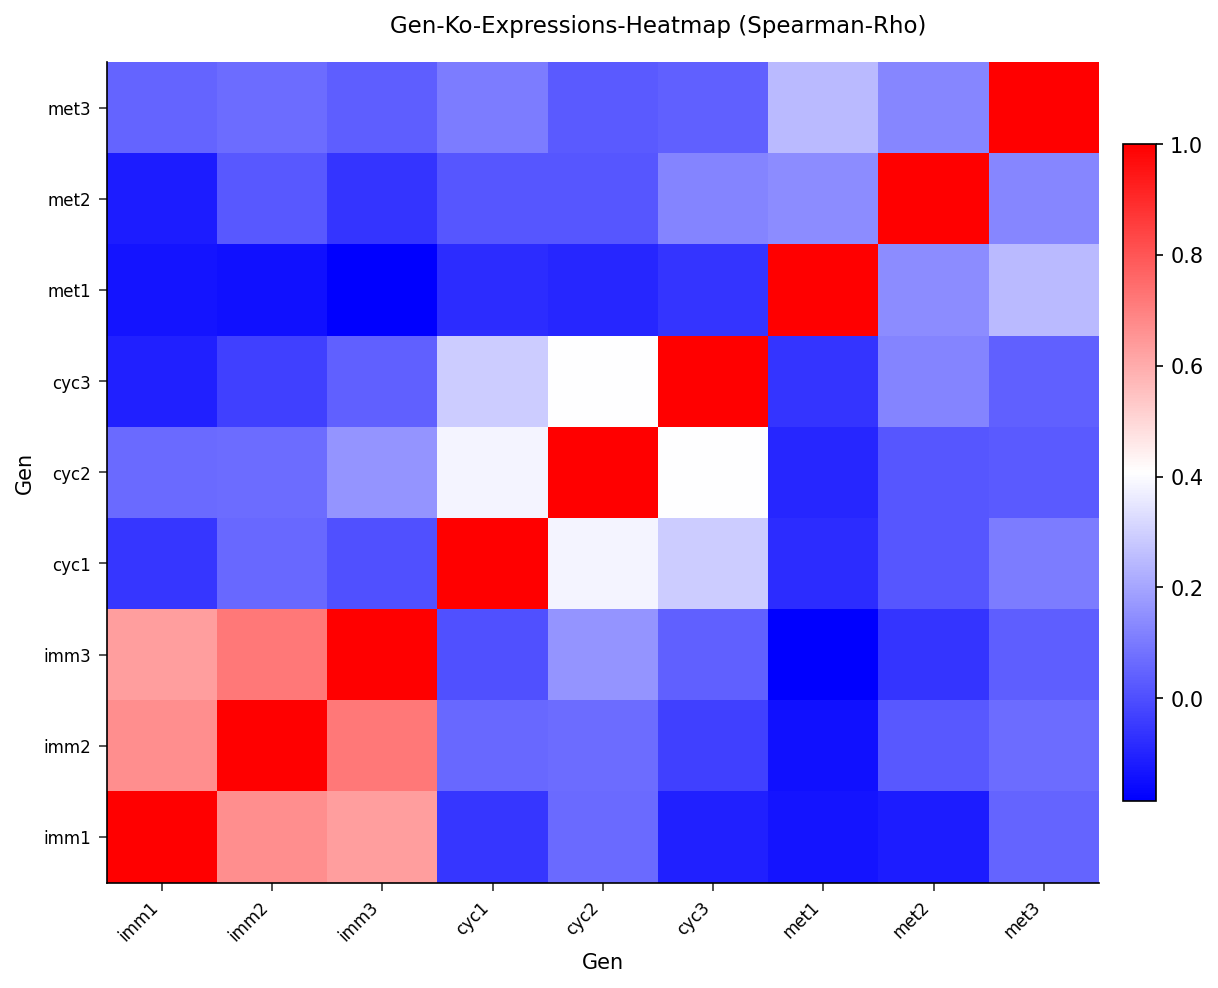

In [6]:
/* --------------------------------------------------------
   Heatmap der vollständigen 9x9-Spearman-Matrix. HEATMAPPARM
   stellt das vorab berechnete rho je Genpaar dar; die Blau-
   Weiß-Rot-Skala zentriert schwache Paare bei Weiß und
   sättigt starke Paare.
   -------------------------------------------------------- */
PROZEDUR SGPLOT DATEN=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS BEZEICHNUNG='Gen' discreteorder=data;
    YAXIS BEZEICHNUNG='Gen' discreteorder=data;
    TITEL 'Gen-Ko-Expressions-Heatmap (Spearman-Rho)';
AUSFÜHREN;
TITEL;

Drei rote Blöcke liegen entlang der Diagonale — die Module immune, cell-cycle und metabolic —, während die umliegenden Zellen nahezu weiß sind. Der immune-Block ist am stärksten gesättigt, passend zu seinen höchsten Korrelationen innerhalb des Moduls in der Matrix oben.

---

In [7]:
/* --------------------------------------------------------
   Netzwerk-Kantenliste: jedes ungeordnete Genpaar (gene_x <
   gene_y) behalten, dessen |rho| einen Schwellenwert erreicht.
   Diese Kanten definieren das Ko-Expressions-Netzwerk für den
   Export in ein Werkzeug wie Cytoscape.
   -------------------------------------------------------- */
DATEN work.network_edges;
    FESTLEGEN work.corr_long(WO=(gene_x < gene_y));
    WENN abs(rho) >= 0.24;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.network_edges noobs;
    VAR gene_x gene_y mod_x mod_y rho;
    BEZEICHNUNG gene_x='Gen X' gene_y='Gen Y' mod_x='Modul X'
                mod_y='Modul Y' rho='Spearman-Rho';
    TITEL 'Ko-Expressions-Netzwerkkanten (|Spearman-Rho| >= 0.24)';
AUSFÜHREN;
TITEL;

/* Kantenliste für externe Netzwerk-Visualisierung exportieren */
PROZEDUR EXPORT DATEN=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

                                 Ko-Expressions-Netzwerkkanten (|Spearman-Rho| >= 0.24)                                 

Gen X  Gen Y  Modul X  Modul Y  Spearman-Rho
imm1   imm2   imm      imm      0.6708351085
imm1   imm3   imm      imm      0.6308427619
imm2   imm3   imm      imm      0.7179122524
cyc1   cyc2   cyc      cyc      0.3821865118
cyc1   cyc3   cyc      cyc       0.288211415
cyc2   cyc3   cyc      cyc      0.4054041891
met1   met3   met      met      0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Interpretation

Die Spearman-Analyse gewann die eingebaute Drei-Modul-Struktur direkt aus 100 Proben zurück. Die untenstehenden Werte sind der PROC-CORR-Matrix und der in diesem Notebook erzeugten Zusammenfassung innerhalb/zwischen der Module entnommen:

- **Das Immunmodul (IMM1-IMM3)** ist der am engsten koexprimierte Block, mit paarweisem rho von etwa 0.63 bis 0.72 (Mittelwert ~0.67) und der stärksten einzelnen Kante zwischen IMM2 und IMM3.
- **Das cell-cycle-Modul (CYC1-CYC3)** ist moderat koexprimiert, mit paarweisem rho von etwa 0.29 bis 0.41 (Mittelwert ~0.36).
- **Das metabolic-Modul (MET1-MET3)** ist der schwächste Block, mit paarweisem rho von etwa 0.13 bis 0.25 (Mittelwert ~0.17) — im Einklang mit seiner kleineren Signalladung im Generator.
- **Paare zwischen den Modulen** liegen im Mittel praktisch bei null (mittleres rho ~-0.01, mittleres |rho| ~0.07, größtes |rho| ~0.18), sodass die drei Module als nahezu unabhängige Gemeinschaften wirken.

Eine Schwellensetzung bei |rho| >= 0.24 ergibt die oben ausgegebene Kantenliste des Netzwerks. Jede überlebende Kante liegt innerhalb eines Moduls: Alle drei Immunpaare und alle drei cell-cycle-Paare überschreiten die Schwelle, ergänzt durch das stärkste metabolic-Paar (MET1-MET3). Kein Paar zwischen den Modulen überlebt, sodass sich das Koexpressionsnetzwerk sauber in die drei biologischen Module trennt. Die Kantenliste wird nach `gene_coexpression_edges.csv` exportiert, zur Visualisierung in einem externen Netzwerkwerkzeug wie Cytoscape.

Dieses durchgearbeitete Beispiel zeigt den zentralen PROC-CORR-Arbeitsablauf für die Koexpressionsanalyse: Wählen Sie einen rangbasierten Koeffizienten, der zu Expressionsdaten passt, lesen Sie die modulare Struktur aus der Korrelationsmatrix ab, quantifizieren Sie die Stärke innerhalb versus zwischen den Modulen und reduzieren Sie die Matrix auf eine schwellenbasierte Kantenliste für die Netzwerkkonstruktion.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>